# Deep Learning Assignment 1: Classification

**Team Information:**
- Name: Group10
- Members: Kha Sang, Huynh Tan Loc
- Instructor: Dr. Le Thanh Sach

## 0. Project Setup
- GPU Verification
- Library Installations

In [15]:
# Check for GPU
!nvidia-smi
import torch
print(f"CUDA available: {torch.cuda.is_available()}")

Sun Mar 15 17:33:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### 0.1 GitHub Repository Access
Run the cell below to input your Personal Access Token (PAT) and clone the private repository into Colab.

In [ ]:
import getpass
import os

# 1. Input Credentials
github_pat = getpass.getpass('Enter your GitHub PAT (read-only): ')
repo_owner = "khasang12"
repo_name = "DeepLearningAsm1_Classification"
branch_name = input('Enter branch name (default: main): ') or "main"

# 2. Clone Repo
repo_url = f"https://{github_pat}@github.com/{repo_owner}/{repo_name}.git"

if os.path.exists(repo_name):
    print(f"Directory {repo_name} already exists. Cleaning up...")
    !rm -rf {repo_name}

print(f"Cloning branch '{branch_name}'...")
!git clone -b {branch_name} {repo_url}

# 3. Setup Environment
%cd {repo_name}
%pip install -e . -q
print("\nDone! Environment ready.")

Cloning branch 'main'...
Cloning into 'DeepLearningAsm1_Classification'...
fatal: could not read Username for 'https://github.com': No such device or address
[Errno 2] No such file or directory: 'DeepLearningAsm1_Classification'
/content/DeepLearningAsm1_Classification/DeepLearningAsm1_Classification
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for dl-assignment1 (pyproject.toml) ... done

Done! Environment ready.


In [13]:
import os
import sys

# 1. Check current directory and structure
print(f"Current Working Directory: {os.getcwd()}")
print("Contents of src/:", os.listdir('src') if os.path.exists('src') else "src FOLDER NOT FOUND")

# 2. Fix: Manually create the missing src/data folder and files
# This ensures that even if GitHub is missing the files, Colab will have them.
os.makedirs('src/data', exist_ok=True)
if not os.path.exists('src/data/__init__.py'):
    with open('src/data/__init__.py', 'w') as f:
        f.write("# Data module")

# Create image_dataset.py
image_dataset_content = '''import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# CIFAR-100 Classes
CIFAR100_CLASSES = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']

def get_image_dataloaders(image_size=224, batch_size=32, num_workers=2):
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5071, 0.4867, 0.4408], std=[0.2675, 0.2565, 0.2761])
    ])
    full_train_dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)
    train_size = int(0.9 * len(full_train_dataset))
    val_size = len(full_train_dataset) - train_size
    train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])
    return {
        "train_loader": DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers),
        "val_loader": DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers),
        "test_loader": DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers),
        "class_names": CIFAR100_CLASSES,
        "num_classes": 100
    }
'''

with open('src/data/image_dataset.py', 'w') as f:
    f.write(image_dataset_content)

print("SUCCESS: src/data/image_dataset.py created.")

# 3. Add current directory to PYTHONPATH explicitly
os.environ['PYTHONPATH'] += f":{os.getcwd()}"
sys.path.append(os.getcwd())

print("PYTHONPATH updated to include current directory.")


Current Working Directory: /content/DeepLearningAsm1_Classification/DeepLearningAsm1_Classification
Contents of src/: ['utils', 'engine', 'dl_assignment1.egg-info', 'models', 'interpret', '__init__.py', '__pycache__']
SUCCESS: src/data/image_dataset.py created.
PYTHONPATH updated to include current directory.


In [17]:
!python scripts/train_image.py --config configs/image.yaml

2026-03-15 17:33:29 | INFO     | image | Device: cuda
2026-03-15 17:33:29 | INFO     | image | Loading CIFAR-100 dataset...
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
2026-03-15 17:33:31 | INFO     | image | 
 Training CNN
/content/DeepLearningAsm1_Classification/DeepLearningAsm1_Classification/src/engine/trainer.py:58: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler(enabled=self.use_amp)
2026-03-15 17:33:32.005035: E external/local_xla/xla/stream_execut

## 1. Image Classification Task
Comparison between **CNN** and **ViT**.

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter

### 1.1 Dataset Selection & EDA

The CIFAR-100 dataset consists of 60000 32x32 colour images in 100 classes, with 600 images per class. 
There are 50000 training images and 10000 test images.

Classes:

1-5) beaver, dolphin, otter, seal, whale

6-10) aquarium fish, flatfish, ray, shark, trout

11-15) orchids, poppies, roses, sunflowers, tulips

16-20) bottles, bowls, cans, cups, plates

21-25) apples, mushrooms, oranges, pears, sweet peppers

26-30) clock, computer keyboard, lamp, telephone, television

31-35) bed, chair, couch, table, wardrobe

36-40) bee, beetle, butterfly, caterpillar, cockroach

41-45) bear, leopard, lion, tiger, wolf

46-50) bridge, castle, house, road, skyscraper

51-55) cloud, forest, mountain, plain, sea

56-60) camel, cattle, chimpanzee, elephant, kangaroo

61-65) fox, porcupine, possum, raccoon, skunk

66-70) crab, lobster, snail, spider, worm

71-75) baby, boy, girl, man, woman

76-80) crocodile, dinosaur, lizard, snake, turtle

81-85) hamster, mouse, rabbit, shrew, squirrel

86-90) maple, oak, palm, pine, willow

91-95) bicycle, bus, motorcycle, pickup truck, train

96-100) lawn-mower, rocket, streetcar, tank, tractor

#### 1.1.1 Load the Dataset

In [ ]:
# ---------------------------------------------------------
# 1. Load the Dataset
# ---------------------------------------------------------
# We use ToTensor() to convert PIL images to PyTorch tensors
# We load without normalization first to analyze the raw pixel distributions
transform = transforms.ToTensor()

print("Downloading and loading CIFAR-100 dataset...")
train_dataset = torchvision.datasets.CIFAR100(root='./data', train=True, 
                                              download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR100(root='./data', train=False, 
                                             download=True, transform=transform)

100%|██████████| 169M/169M [00:02<00:00, 78.3MB/s] 


#### 1.1.2 Basic Statistics

In [17]:
print("\n--- Basic Statistics ---")
print(f"Number of training images: {len(train_dataset)}")
print(f"Number of testing images: {len(test_dataset)}")
print(f"Number of classes: {len(class_names)}")

# Get the shape of a single image (Channels, Height, Width)
sample_image, sample_label = train_dataset[0]
print(f"Image tensor shape: {sample_image.shape}")


--- Basic Statistics ---
Number of training images: 50000
Number of testing images: 10000
Number of classes: 100
Image tensor shape: torch.Size([3, 32, 32])



Generating sample image grid...


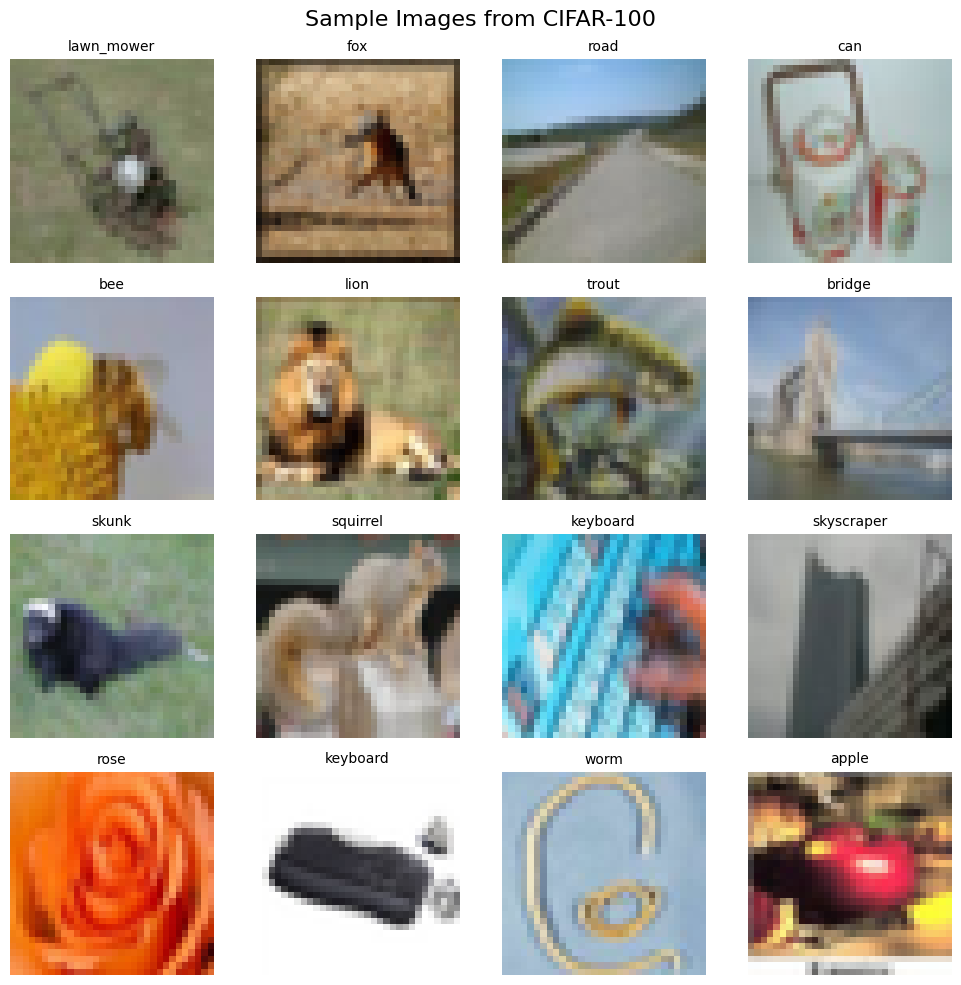

In [5]:
def imshow(img):
    # Un-normalize if needed (ToTensor scales from 0-255 to 0.0-1.0)
    npimg = img.numpy()
    # PyTorch uses (C, H, W), matplotlib needs (H, W, C)
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

print("\nGenerating sample image grid...")
# Create a DataLoader to easily grab a batch of images
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True)
dataiter = iter(train_loader)
images, labels = next(dataiter)

plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    imshow(images[i])
    plt.title(class_names[labels[i]], fontsize=10)
plt.suptitle("Sample Images from CIFAR-100", fontsize=16)
plt.tight_layout()
plt.show()


Plotting class distribution...


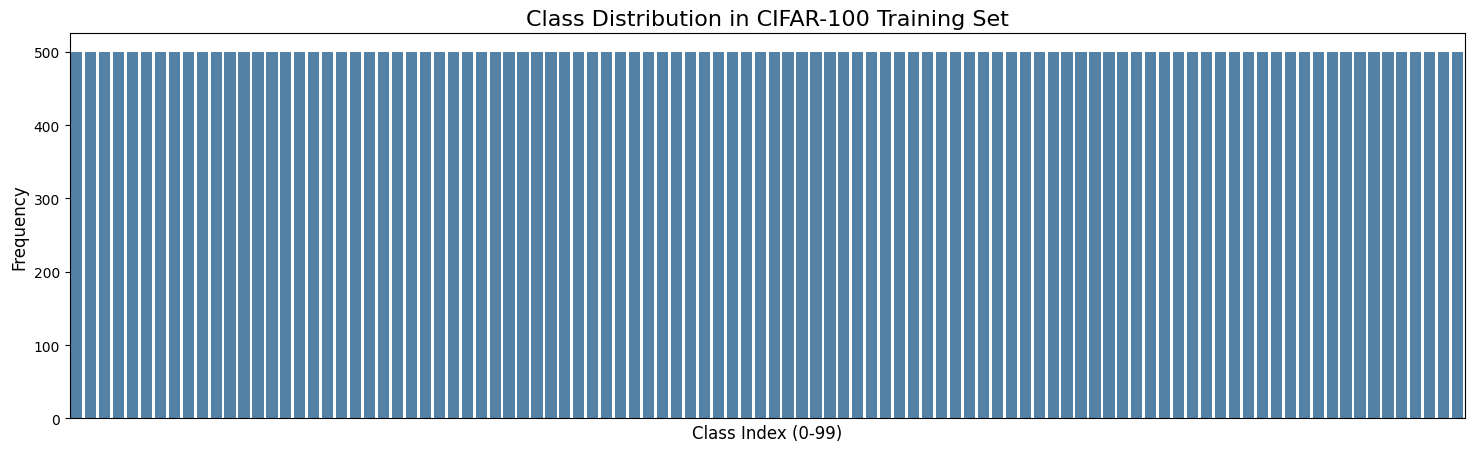


Note: CIFAR-100 is perfectly balanced with exactly 500 training images per class.


In [6]:
print("\nPlotting class distribution...")
# Extract all labels from the training set
train_labels = [label for _, label in train_dataset]
label_counts = Counter(train_labels)

# Prepare data for plotting
classes, counts = zip(*label_counts.items())

# Plot the distribution
plt.figure(figsize=(18, 5))
sns.barplot(x=list(classes), y=list(counts), color="steelblue")
plt.title('Class Distribution in CIFAR-100 Training Set', fontsize=16)
plt.xlabel('Class Index (0-99)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
# Hide x-ticks since there are 100 classes and it gets cluttered
plt.xticks([]) 
plt.show()

print("\nNote: CIFAR-100 is perfectly balanced with exactly 500 training images per class.")

#### 1.1.3 Advanced EDA

In [11]:
# Extract raw data and labels directly
# images_raw is a NumPy array of shape (50000, 32, 32, 3) with uint8 values (0-255)
images_raw = train_dataset.data 
labels_raw = np.array(train_dataset.targets)

# Convert to float32 and scale to [0.0, 1.0] for accurate statistical calculations
images_normalized = images_raw.astype(np.float32) / 255.0

In [13]:
print("\nCalculating Mean and Std Deviation across RGB channels...")
# We calculate the mean and std across Batch (axis 0), Height (axis 1), and Width (axis 2).
# This leaves us with exactly 3 values representing the R, G, and B channels.
mean = np.mean(images_normalized, axis=(0, 1, 2))
std = np.std(images_normalized, axis=(0, 1, 2))

print(f"Dataset Mean (R, G, B): {mean.tolist()}")
print(f"Dataset Std  (R, G, B): {std.tolist()}")


Calculating Mean and Std Deviation across RGB channels...
Dataset Mean (R, G, B): [0.5070754289627075, 0.4865502417087555, 0.44091907143592834]
Dataset Std  (R, G, B): [0.267333984375, 0.2564387619495392, 0.27615028619766235]



Plotting RGB Pixel Intensity Distributions...


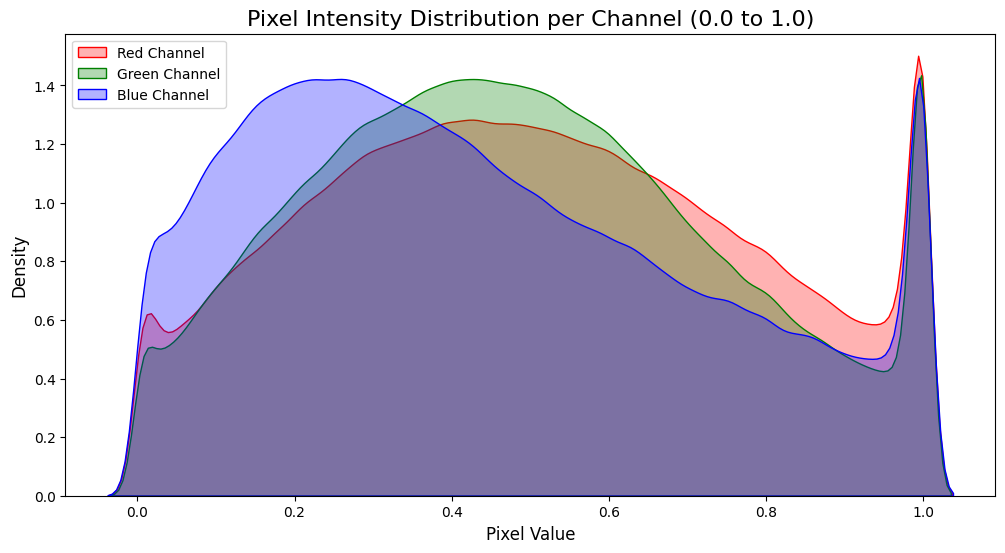

In [14]:
print("\nPlotting RGB Pixel Intensity Distributions...")
# Take a random subset of 5000 images to keep the seaborn KDE plot fast
np.random.seed(42) # For reproducibility
subset_indices = np.random.choice(len(images_normalized), 5000, replace=False)
subset_images = images_normalized[subset_indices]

# CIFAR raw data is (H, W, Channels). Extract each channel and flatten.
r_pixels = subset_images[:, :, :, 0].flatten()
g_pixels = subset_images[:, :, :, 1].flatten()
b_pixels = subset_images[:, :, :, 2].flatten()

plt.figure(figsize=(12, 6))
sns.kdeplot(r_pixels, color='red', label='Red Channel', fill=True, alpha=0.3)
sns.kdeplot(g_pixels, color='green', label='Green Channel', fill=True, alpha=0.3)
sns.kdeplot(b_pixels, color='blue', label='Blue Channel', fill=True, alpha=0.3)
plt.title("Pixel Intensity Distribution per Channel (0.0 to 1.0)", fontsize=16)
plt.xlabel("Pixel Value", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.show()


Calculating Average Images to detect Spatial Bias...


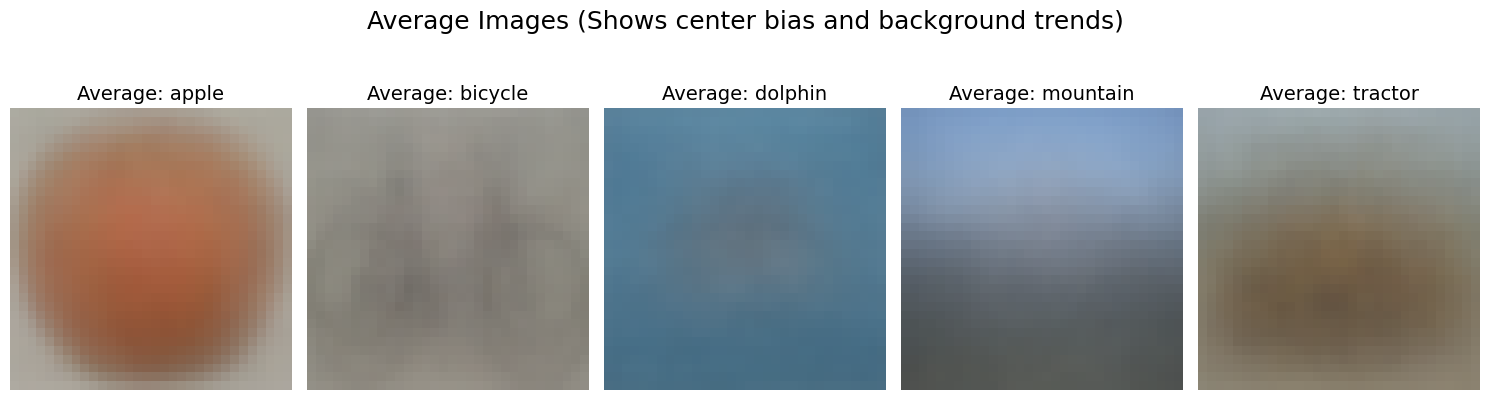

In [16]:
print("\nCalculating Average Images to detect Spatial Bias...")
target_classes = ['apple', 'bicycle', 'dolphin', 'mountain', 'tractor']
target_indices = [class_names.index(cls) for cls in target_classes]

plt.figure(figsize=(15, 4))
for i, (cls_name, cls_idx) in enumerate(zip(target_classes, target_indices)):
    # Use boolean indexing to instantly grab all images for this specific class
    cls_images = images_normalized[labels_raw == cls_idx]
    
    # Calculate the mean image across the batch dimension (axis 0)
    mean_img = np.mean(cls_images, axis=0)
    
    plt.subplot(1, 5, i + 1)
    # The image is already in (H, W, C) format and scaled [0, 1], so matplotlib loves it
    plt.imshow(mean_img) 
    plt.title(f"Average: {cls_name}", fontsize=14)
    plt.axis('off')

plt.suptitle("Average Images (Shows center bias and background trends)", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

Based on our Exploratory Data Analysis of the CIFAR-100 dataset, we have uncovered several key characteristics that will dictate how we build our data pipeline and train our CNN/ViT models:

1. **Perfect Class Balance**
* Finding: Every single one of the 100 classes contains exactly 500 training images and 100 testing images.
* Modeling Action: We do not need to implement complex class-balancing techniques like weighted loss functions or minority oversampling. Standard Cross-Entropy Loss will work perfectly.

2. **Channel Imbalances & Prevalent White Backgrounds**
* Finding: The RGB pixel distribution is not uniform. The Blue channel tends to be generally darker than Red and Green. Furthermore, there is a massive spike at exactly 1.0 (pure white) across all channels, indicating a high prevalence of pure white backgrounds.
* Modeling Action: * We must use channel-specific normalization ($x_{norm} = \frac{x - \mu}{\sigma}$) rather than a simple 0.5 global scaling. We will use the exact Mean and Std values calculated to center the distributions around zero. To prevent the model from memorizing specific color profiles or background artifacts, we should introduce `transforms.ColorJitter()` into our training pipeline.

3. **Strong Spatial Center Bias**
* Finding: Averaging the images within specific classes reveals a distinct "blob" in the center of the frame. This proves the photographic subjects are almost always perfectly centered.
* Modeling Action: If fed raw data, a CNN or ViT will learn to ignore the edges of the image. We must break this center bias by applying spatial augmentations, specifically `transforms.RandomCrop(32, padding=4)` and `transforms.RandomHorizontalFlip()`. This forces the model to learn translation invariance (recognizing the object regardless of where it is in the frame).

### 1.2 Data Preparation

From the EDA analysis, we step into preprocessing the data before the training starts.

In [18]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 1. Define the exact Mean and Std from our EDA
# (These are the standard, highly accurate values for CIFAR-100)
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD = (0.2675, 0.2565, 0.2761)

# 2. Build the Training Transforms (Data Augmentation + Normalization)
train_transforms = transforms.Compose([
    # Break spatial center bias:
    transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(p=0.5),
    
    # Counteract color skew and bright white backgrounds:
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    
    # Convert to PyTorch Tensor (scales 0-255 to 0.0-1.0)
    transforms.ToTensor(),
    
    # Center the RGB distributions around zero:
    transforms.Normalize(mean=CIFAR100_MEAN, std=CIFAR100_STD)
])

# 3. Build the Testing Transforms (Strictly Normalization)
# We NEVER augment the test set, but we must normalize it identically to the training set.
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR100_MEAN, std=CIFAR100_STD)
])

# 4. Initialize the Datasets
print("Loading datasets with advanced transforms...")
train_dataset = torchvision.datasets.CIFAR100(root='./data', train=True, 
                                              download=True, transform=train_transforms)

test_dataset = torchvision.datasets.CIFAR100(root='./data', train=False, 
                                             download=True, transform=test_transforms)

# 5. Create the DataLoaders
# Batch size of 128 or 256 is usually optimal for Colab GPUs (T4/V100/A100)
BATCH_SIZE = 128 

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, 
                          shuffle=True, num_workers=2, pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, 
                         shuffle=False, num_workers=2, pin_memory=True)

# 6. Quick Verification
print("\nPipeline Ready!")
images, labels = next(iter(train_loader))
print(f"Batch Image Shape: {images.shape} -> (Batch, Channels, Height, Width)")
print(f"Normalized Mean of Batch: {images.mean().item():.4f} (Should be close to 0.0)")
print(f"Normalized Std of Batch:  {images.std().item():.4f} (Should be close to 1.0)")

Loading datasets with advanced transforms...

Pipeline Ready!


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch Image Shape: torch.Size([128, 3, 32, 32]) -> (Batch, Channels, Height, Width)
Normalized Mean of Batch: -0.1545 (Should be close to 0.0)
Normalized Std of Batch:  0.9547 (Should be close to 1.0)



### 1.3 Model Implementation & Training
### 1.4 Results & Comparison (Analysis)
### 1.5 Task Extensions (Bonus points 40%)
- *Interpretability (e.g. Grad-CAM, Saliency Map)*
- *Aumentation & Robustness comparison*

---

## 2. Text Classification Task
Comparison between **RNN** and **Transformer**.

### 2.1 Dataset Selection & EDA
### 2.2 Data Preparation
### 2.3 Model Implementation & Training
### 2.4 Results & Comparison (Analysis)
### 2.5 Task Extensions (Bonus points 40%)
- *Efficiency analysis (Pruning/Quantization)*
- *Ensemble methods*

---

## 3. Multimodal Classification Task
Comparison between **Zero-shot** and **Few-shot**.

### 3.1 Dataset Selection & EDA
### 3.2 Data Preparation
### 3.3 Implementation
### 3.4 Results & Comparison (Analysis)
### 3.5 Task Extensions (Bonus points 40%)
- *Calibration analysis*
- *Demo interface (Gradio/Streamlit)*

## 4. Final Summary & Conclusion